In [1]:
install.packages(c("lavaan", "psych", "GPArotation", "semPlot"))
library(lavaan)
library(psych)
library(GPArotation)
library(semPlot)

Installing packages into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘checkmate’, ‘coda’, ‘rbibutils’, ‘gridExtra’, ‘htmlTable’, ‘Formula’, ‘arm’, ‘Rdpack’, ‘minqa’, ‘nloptr’, ‘openxlsx’, ‘RUnit’, ‘mvtnorm’, ‘Hmisc’, ‘jpeg’, ‘png’, ‘reshape2’, ‘glasso’, ‘fdrtool’, ‘gtools’, ‘pbapply’, ‘abind’, ‘mi’, ‘lme4’, ‘carData’, ‘kutils’, ‘reformulas’, ‘RcppParallel’, ‘RcppEigen’, ‘StanHeaders’, ‘BH’, ‘rpf’, ‘mnormt’, ‘pbivnorm’, ‘numDeriv’, ‘quadprog’, ‘qgraph’, ‘sem’, ‘plyr’, ‘XML’, ‘igraph’, ‘lisrelToR’, ‘rockchalk’, ‘colorspace’, ‘corpcor’, ‘OpenMx’


This is lavaan 0.6-21
lavaan is FREE software! Please report any bugs.


Attaching package: ‘psych’


The following object is masked from ‘package:lavaan’:

    cor2cov



Attaching package: ‘GPArotation’


The following objects are masked from ‘package:psych’:

    equamax, varimin




# VERİ

In [2]:
d <- read.csv("autism.csv")
set.seed(42)
idx <- sample(nrow(d), floor(nrow(d) / 2))
d_efa <- d[idx, ]
d_cfa <- d[-idx, ]
dim(d_efa)
dim(d_cfa)

[1] 100  11

[1] 100  11

# MODEL-DEĞERLENDİRME (EFA)

In [3]:
R <- cor(d_efa)
lambda <- eigen(R)$values
lambda
nf <- sum(lambda > 1)
nf
efa <- principal(r = R, nfactors = nf, rotate = "varimax", n.obs = nrow(d_efa))
print(efa$loadings, cutoff = 0.30)
efa$Vaccounted

[1] 5.2802455 1.3986067 1.1948905 0.6830363 0.5264409 0.4703620 0.3931272
 [8] 0.3325396 0.2704886 0.2398898 0.2103728

[1] 3


Loadings:
               RC1   RC3   RC2  
taklit                     0.844
esleme         0.312       0.732
alici_dil                  0.832
mand_t1        0.839 0.302      
tact_t1        0.773            
intraverbal_t1 0.826            
sosyal_t1      0.696 0.344      
mand_t2        0.307 0.723      
tact_t2              0.822      
intraverbal_t2       0.852      
sosyal_t2      0.341 0.698      

                 RC1   RC3   RC2
SS loadings    2.873 2.775 2.226
Proportion Var 0.261 0.252 0.202
Cumulative Var 0.261 0.513 0.716


,RC1,RC3,RC2
SS loadings,2.8725554,2.7747152,2.2264721
Proportion Var,0.2611414,0.2522468,0.2024066
Cumulative Var,0.2611414,0.5133882,0.7157948
Proportion Explained,0.3648272,0.3524010,0.2827718
Cumulative Proportion,0.3648272,0.7172282,1.0000000


# MODEL-DEĞERLENDİRME (CFA)

In [4]:
model_cfa <- '
  F1 =~ taklit + esleme + alici_dil
  F2 =~ mand_t1 + tact_t1 + intraverbal_t1 + sosyal_t1
  F3 =~ mand_t2 + tact_t2 + intraverbal_t2 + sosyal_t2
'
fit_cfa <- cfa(model_cfa, data = d_cfa, estimator = "ML")
summary(fit_cfa, fit.measures = TRUE, standardized = TRUE)
fitMeasures(fit_cfa, c("chisq", "df", "pvalue", "rmsea", "cfi", "tli", "srmr"))

lhs,op,rhs,exo,est,se,z,pvalue,std.lv,std.all
<chr>,<chr>,<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
F1,=~,taklit,0,1.0000000,0.0000000,NA,NA,8.7821896,0.6984360
F1,=~,esleme,0,0.9608730,0.1639468,5.860882,4.604146e-09,8.4385688,0.7067838
F1,=~,alici_dil,0,1.1509875,0.1857962,6.194894,5.832435e-10,10.1081908,0.8097342
F2,=~,mand_t1,0,1.0000000,0.0000000,NA,NA,9.2696187,0.6786349
F2,=~,tact_t1,0,1.0874274,0.1675533,6.490038,8.581491e-11,10.0800370,0.7518178
F2,=~,intraverbal_t1,0,1.1524218,0.1704229,6.762129,1.359779e-11,10.6825104,0.7921495
F2,=~,sosyal_t1,0,1.1304450,0.1676426,6.743186,1.549494e-11,10.4787937,0.7891973
F3,=~,mand_t2,0,1.0000000,0.0000000,NA,NA,9.2844723,0.7724318
F3,=~,tact_t2,0,0.9723271,0.1464073,6.641249,3.110356e-11,9.0275437,0.6847157


chisq     df pvalue  rmsea    cfi    tli   srmr 
52.051 41.000  0.116  0.052  0.976  0.968  0.050

# MODEL-DEĞERLENDİRME (SEM)

lhs,op,rhs,label,exo,est,se,z,pvalue,std.lv,std.all
<chr>,<chr>,<chr>,<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
F1,=~,taklit,,0,1.0000000,0.0000000,NA,NA,8.7821997,0.6984366
F1,=~,esleme,,0,0.9608721,0.1639466,5.860886,4.604053e-09,8.4385709,0.7067839
F1,=~,alici_dil,,0,1.1509857,0.1857958,6.194897,5.832326e-10,10.1081865,0.8097338
F2,=~,mand_t1,,0,1.0000000,0.0000000,NA,NA,9.2696005,0.6786342
F2,=~,tact_t1,,0,1.0874288,0.1675538,6.490027,8.582113e-11,10.0800302,0.7518175
F2,=~,intraverbal_t1,,0,1.1524237,0.1704234,6.762119,1.359868e-11,10.6825075,0.7921495
F2,=~,sosyal_t1,,0,1.1304468,0.1676431,6.743176,1.549627e-11,10.4787902,0.7891972
F3,=~,mand_t2,,0,1.0000000,0.0000000,NA,NA,9.2844821,0.7724322
F3,=~,tact_t2,,0,0.9723259,0.1464070,6.641251,3.110312e-11,9.0275428,0.6847157


chisq     df pvalue  rmsea    cfi    tli   srmr 
52.051 41.000  0.116  0.052  0.976  0.968  0.050

lhs,op,rhs,label,est,se,z,pvalue,ci.lower,ci.upper
<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
F1,=~,taklit,,1.0000000,0.0000000,NA,NA,1.00000000,1.0000000
F1,=~,esleme,,0.9608721,0.1639466,5.860886,4.604053e-09,0.63954274,1.2822015
F1,=~,alici_dil,,1.1509857,0.1857958,6.194897,5.832326e-10,0.78683267,1.5151388
F2,=~,mand_t1,,1.0000000,0.0000000,NA,NA,1.00000000,1.0000000
F2,=~,tact_t1,,1.0874288,0.1675538,6.490027,8.582113e-11,0.75902932,1.4158282
F2,=~,intraverbal_t1,,1.1524237,0.1704234,6.762119,1.359868e-11,0.81839990,1.4864475
F2,=~,sosyal_t1,,1.1304468,0.1676431,6.743176,1.549627e-11,0.80187238,1.4590212
F3,=~,mand_t2,,1.0000000,0.0000000,NA,NA,1.00000000,1.0000000
F3,=~,tact_t2,,0.9723259,0.1464070,6.641251,3.110312e-11,0.68537340,1.2592785


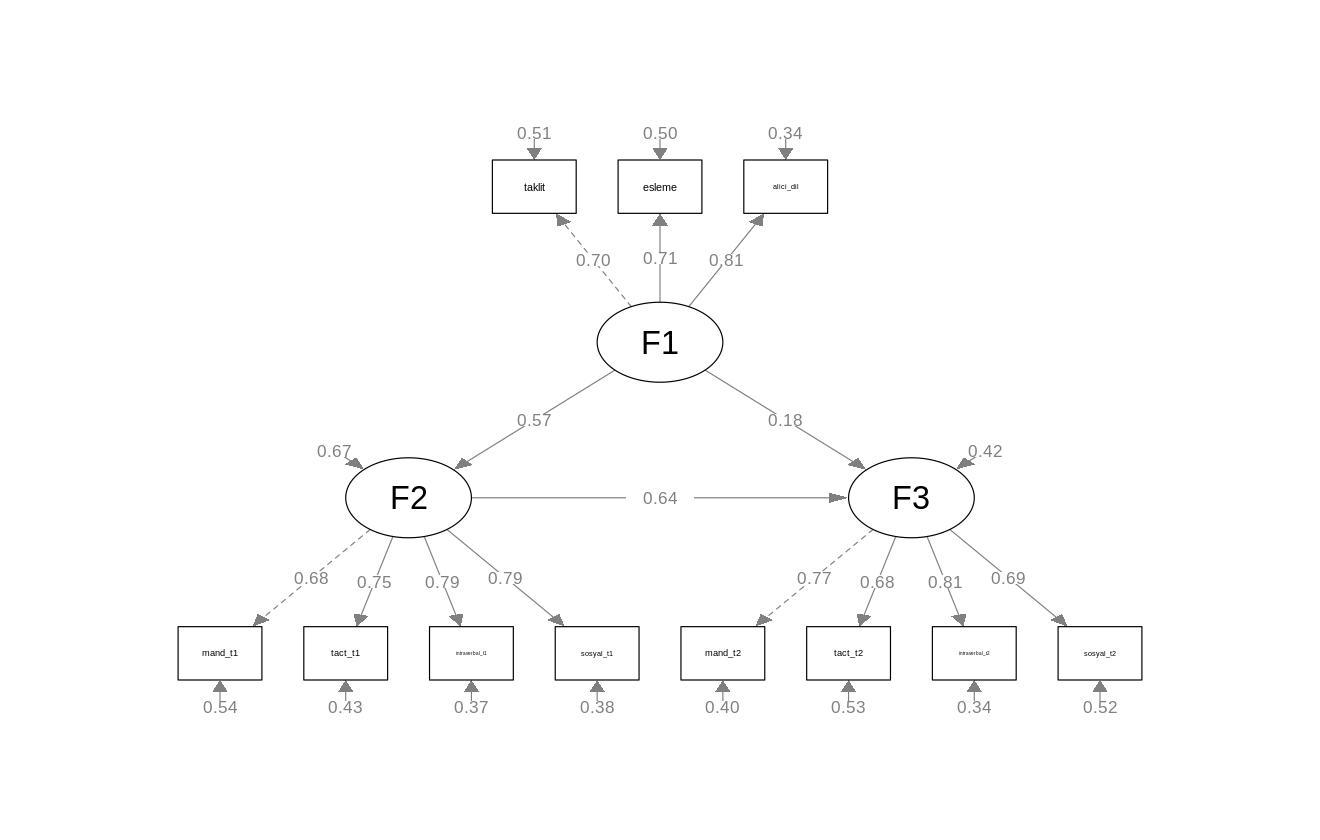

In [5]:
model_sem <- '
  F1 =~ taklit + esleme + alici_dil
  F2 =~ mand_t1 + tact_t1 + intraverbal_t1 + sosyal_t1
  F3 =~ mand_t2 + tact_t2 + intraverbal_t2 + sosyal_t2

  F2 ~ a*F1
  F3 ~ c*F1 + b*F2

  DE := c
  IE := a*b
  TE := c + a*b
'
fit_sem <- sem(model_sem, data = d_cfa, estimator = "ML")
summary(fit_sem, fit.measures = TRUE, standardized = TRUE, rsquare = TRUE)
fitMeasures(fit_sem, c("chisq", "df", "pvalue", "rmsea", "cfi", "tli", "srmr"))
parameterEstimates(fit_sem, ci = TRUE)

options(repr.plot.width = 11, repr.plot.height = 7)
semPaths(fit_sem,
         whatLabels = "std",
         layout = "tree2",
         style = "lisrel",
         edge.label.cex = 0.9,
         nCharNodes = 0,
         sizeLat = 9,
         sizeMan = 6)